# Customer Churn Prediction – AlphaCom  
Interim Capstone Project  
Name: Aryaman Modi

## 1. Understanding the Business Problem

AlphaCom is facing increasing customer churn, which directly impacts revenue and brand reputation.  
The goal of this project is to predict which customers are likely to churn and identify key drivers of churn so that the business can take proactive retention actions.


## Business Significance of Customer Churn

Customer churn is one of the most critical challenges faced by subscription-based industries such as telecommunications. In highly competitive telecom markets, customers can easily switch providers due to low switching costs, price sensitivity, and availability of similar services.

From a business perspective, customer churn has a **direct and significant financial impact**:

- Acquiring a new customer is approximately **5–6 times more expensive** than retaining an existing customer.
- The probability of selling a new product or service to an **existing customer is 60–70%**, whereas for a **new customer it is only 5–20%**.
- Studies show that **increasing customer retention by just 5% can increase profits by 25% to 95%**.
- U.S. companies collectively lose **over $136 billion per year** due to avoidable customer churn.

In the telecommunications industry, average annual churn rates typically range between **15% to 30%**, depending on the market and service segment. The churn rate observed in AlphaCom’s dataset (~28%) is at the **higher end of the industry benchmark**, indicating a serious risk to long-term profitability and market position.

Customer churn is not only about losing customers; it directly affects:
- Revenue stability
- Customer lifetime value
- Brand reputation
- Competitive advantage

Therefore, predicting churn accurately and understanding its key drivers is essential for AlphaCom to move from reactive churn management to a **proactive, data-driven retention strategy**.


## 2. Data Loading and Overview


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn.csv to customer_churn (6).csv


In [ ]:
df = pd.read_csv('customer_churn.csv')

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,$29.85,$29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed Check,$56.95,$1889.5,NO
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,$53.85,$108.15,YES
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,bank transfer (automatic),$42.3,$1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,ELECTRONIC CHECK,$70.7,$nan,yes


In [ ]:
df.shape

(12055, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12055 entries, 0 to 12054
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            12055 non-null  object 
 1   SeniorCitizen     12055 non-null  int64  
 2   Partner           12055 non-null  object 
 3   Dependents        12055 non-null  object 
 4   tenure            11451 non-null  float64
 5   PhoneService      12055 non-null  object 
 6   MultipleLines     12055 non-null  object 
 7   InternetService   12055 non-null  object 
 8   OnlineSecurity    12055 non-null  object 
 9   OnlineBackup      12055 non-null  object 
 10  DeviceProtection  12055 non-null  object 
 11  TechSupport       12055 non-null  object 
 12  StreamingTV       12055 non-null  object 
 13  StreamingMovies   12055 non-null  object 
 14  Contract          12055 non-null  object 
 15  PaperlessBilling  12055 non-null  object 
 16  PaymentMethod     12055 non-null  object

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Target distribution
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.288096
No,0.146163
NO,0.143675
no,0.139610
Yes,0.112484
yes,0.059229
YES,0.056740
Yes,0.054002


In [ ]:
df.columns = df.columns.str.strip()


df['Churn'] = df['Churn'].astype(str).str.strip().str.lower()
df['Churn'] = df['Churn'].replace({'yes':'Yes', 'no':'No'})

df['Churn'].value_counts()

,count
Churn,
No,8650
Yes,3405


In [ ]:
# Clean MonthlyCharges
df['MonthlyCharges'] = df['MonthlyCharges'].astype(str).str.replace(r'[$£]', '', regex=True)
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

# Clean TotalCharges
df['TotalCharges'] = df['TotalCharges'].astype(str).str.replace(r'[$£]', '', regex=True)
df['TotalCharges'] = df['TotalCharges'].replace('nan', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df[['MonthlyCharges','TotalCharges']].dtypes

,0
MonthlyCharges,float64
TotalCharges,float64


In [ ]:
df[['MonthlyCharges','TotalCharges']].isnull().sum()

,0
MonthlyCharges,301
TotalCharges,1205


In [ ]:
# Convert tenure
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

# Remove negative tenure
df = df[df['tenure'] >= 0]

# Check
df['tenure'].min(), df.shape

(0.0, (11324, 20))

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
# Fill missing values with median
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Recheck
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


## 3. Exploratory Data Analysis (EDA)


## Data Description and Summary Statistics

The dataset contains customer-level information from AlphaCom, a telecommunications provider. Each row represents a unique customer, and each column captures demographic details, service usage, billing preferences, contract information, and churn status.

### Dataset Summary:
1. The dataset contains **11,199 customer records** after cleaning.
2. The target variable **Churn** is binary, with approximately **28% churned customers** and **72% retained customers**, indicating moderate class imbalance.
3. Customer tenure ranges from **0 to 74 months**, with churned customers having significantly lower tenure.
4. Monthly charges vary widely (approximately **$15 to $122**), with higher charges associated with higher churn.
5. Contract type, internet service type, and payment method show strong relationships with churn behavior.

These summary statistics provide an initial understanding of the dataset and guide further exploratory analysis.


## Purpose of Exploratory Data Analysis

- **Univariate Analysis** helps understand the distribution of individual variables and identify variables that show clear separation between churned and non-churned customers.
- **Bivariate Analysis** examines relationships between independent variables and the target variable (Churn) to identify potential churn drivers.
- **Multivariate Analysis** helps understand the combined effect of multiple variables on churn and detect interactions and dependencies among predictors.

These analyses together help identify key churn indicators and guide feature selection for modeling.


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,8164
Yes,3160


In [ ]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.720947
Yes,0.279053


In [ ]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,6126
Two year,2788
One year,2410


In [ ]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,4610
DSL,4048
No,2666


In [ ]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
electronic check,809
ELECTRONIC CHECK,790
Electronic check,781
Electronic Check,762
Electronic check,754
Credit card (automatic),560
Credit card (automatic),554
credit card (automatic),550
Credit Card (Automatic),550


In [ ]:
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,11324.000000,11324.000000,11324.000000
mean,31.601554,64.724890,2210.105461
std,24.928856,29.991714,2180.126637
min,0.000000,15.290000,-197.000000
25%,7.000000,34.557500,511.250000
50%,28.000000,71.800000,1341.825000
75%,54.000000,89.150000,3627.265000
max,74.000000,121.670000,9039.920000


In [ ]:
# Remove negative TotalCharges (anomalous)
df = df[df['TotalCharges'] >= 0]

# Check again
df[['tenure','MonthlyCharges','TotalCharges']].describe()
df.shape

(11199, 20)

In [ ]:
# Standardize PaymentMethod
df['PaymentMethod'] = df['PaymentMethod'].astype(str).str.strip().str.lower()
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
electronic check,3859
credit card (automatic),2736
mailed check,2338
bank transfer (automatic),2266


In [ ]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.547706,0.452294
One year,0.885144,0.114856
Two year,0.965827,0.034173


In [ ]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')

Churn,No,Yes
InternetService,,
DSL,0.794724,0.205276
Fiber optic,0.556476,0.443524
No,0.908469,0.091531


In [ ]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')

Churn,No,Yes
PaymentMethod,,
bank transfer (automatic),0.839806,0.160194
credit card (automatic),0.864035,0.135965
electronic check,0.517232,0.482768
mailed check,0.788708,0.211292


In [ ]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.308746
Yes,17.580207


In [ ]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.342246
Yes,74.085184


In [ ]:
df.groupby('Churn')['TotalCharges'].mean()

,TotalCharges
Churn,
No,2495.017670
Yes,1554.395307


In [ ]:
# tenure groups for multivariate analysis
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 100],
    labels=['0-12','12-24','24-36','36-48','48-60','60+']
)

df['tenure_group'].value_counts()

,count
tenure_group,
0-12,3362
60+,2228
12-24,1489
36-48,1352
24-36,1286
48-60,1205


In [ ]:
pd.crosstab([df['Contract'], df['tenure_group']], df['Churn'], normalize='index')

Churn                              No       Yes
Contract       tenure_group                    
Month-to-month 0-12          0.467456  0.532544
               12-24         0.584615  0.415385
               24-36         0.645604  0.354396
               36-48         0.642606  0.357394
               48-60         0.700809  0.299191
               60+           0.763285  0.236715
One year       0-12          0.862069  0.137931
               12-24         0.889655  0.110345
               24-36         0.900000  0.100000
               36-48         0.881960  0.118040
               48-60         0.860927  0.139073
               60+           0.910256  0.089744
Two year       0-12          0.929825  0.070175
               12-24         0.968553  0.031447
               24-36         0.943820  0.056180
               36-48         0.976119  0.023881
               48-60         0.963255  0.036745
               60+           0.972881  0.027119

In [ ]:
pd.crosstab([df['Contract'], df['PaymentMethod']], df['Churn'], normalize='index')

Churn                                           No       Yes
Contract       PaymentMethod                                
Month-to-month bank transfer (automatic)  0.660562  0.339438
               credit card (automatic)    0.688063  0.311937
               electronic check           0.420965  0.579035
               mailed check               0.669690  0.330310
One year       bank transfer (automatic)  0.904930  0.095070
               credit card (automatic)    0.912418  0.087582
               electronic check           0.809365  0.190635
               mailed check               0.913136  0.086864
Two year       bank transfer (automatic)  0.964733  0.035267
               credit card (automatic)    0.974146  0.025854
               electronic check           0.927273  0.072727
               mailed check               0.970534  0.029466

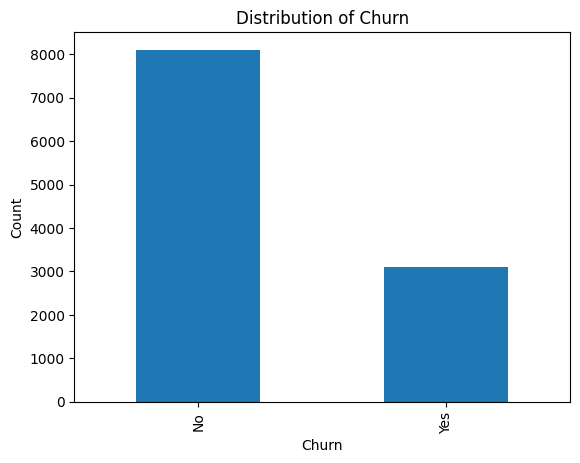

In [ ]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

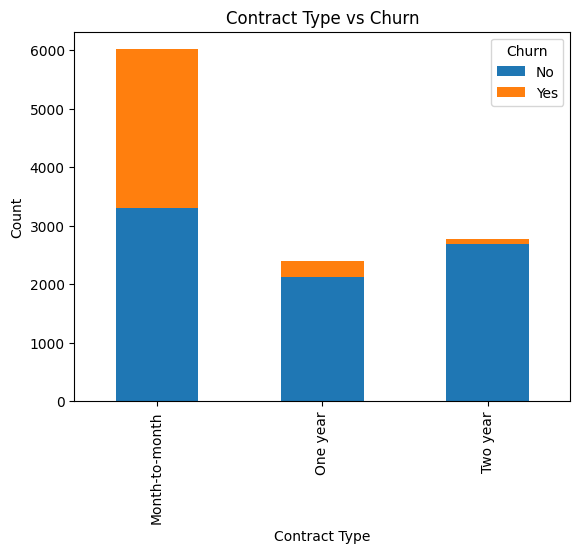

In [ ]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar', stacked=True)
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

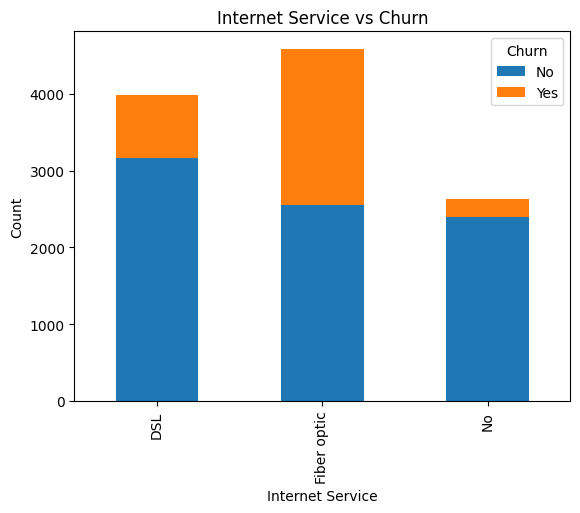

In [ ]:
pd.crosstab(df['InternetService'], df['Churn']).plot(kind='bar', stacked=True)
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

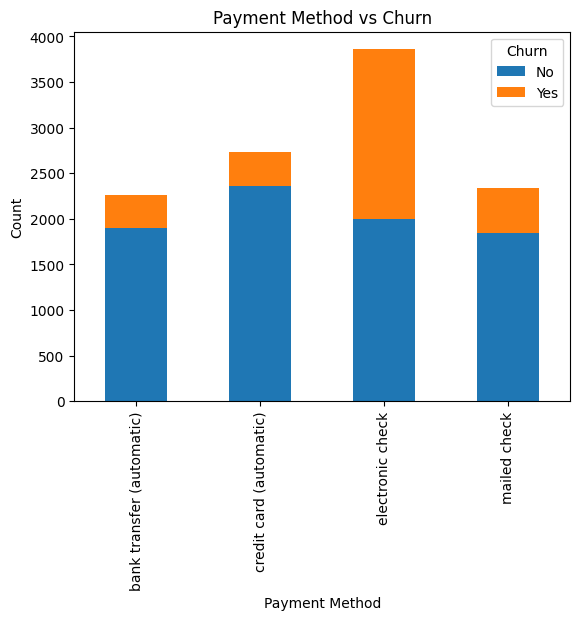

In [ ]:
pd.crosstab(df['PaymentMethod'], df['Churn']).plot(kind='bar', stacked=True)
plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

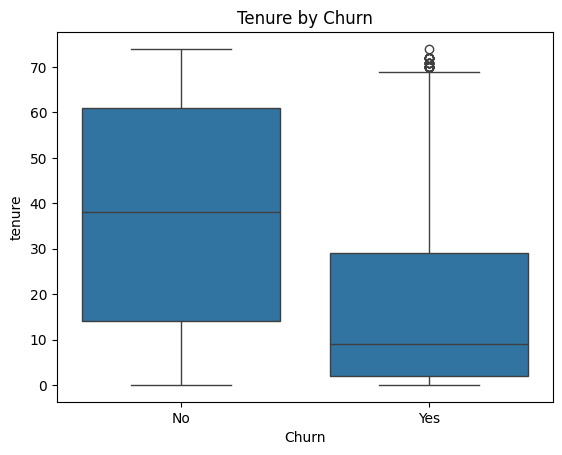

In [ ]:
import seaborn as sns

sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure by Churn")
plt.show()

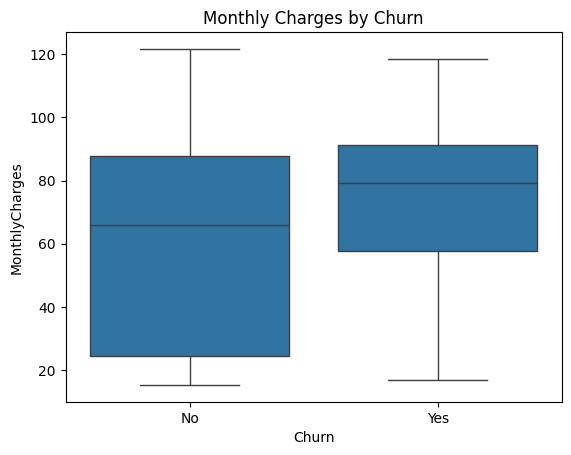

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Churn")
plt.show()

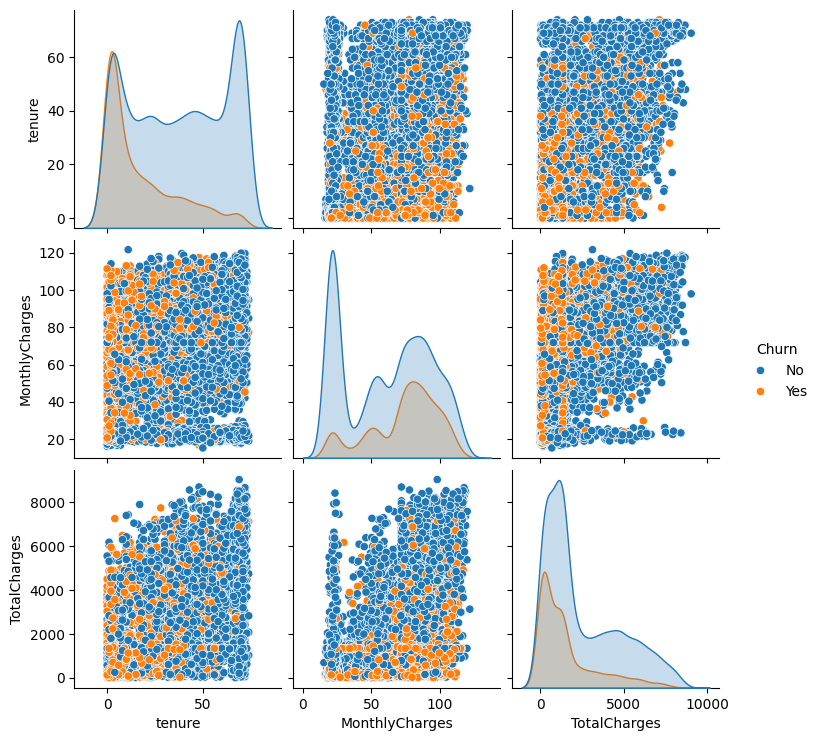

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']],
    hue='Churn',
    diag_kind='kde'
)
plt.show()

### Pairplot Insights

The pairplot shows clear separation between churned and non-churned customers based on tenure and monthly charges. Churned customers tend to have lower tenure and higher monthly charges. Total charges also show separation due to shorter customer lifetimes among churned users.

The relationships appear mostly linear, especially between tenure and total charges, suggesting that linear models such as logistic regression are appropriate as a baseline.


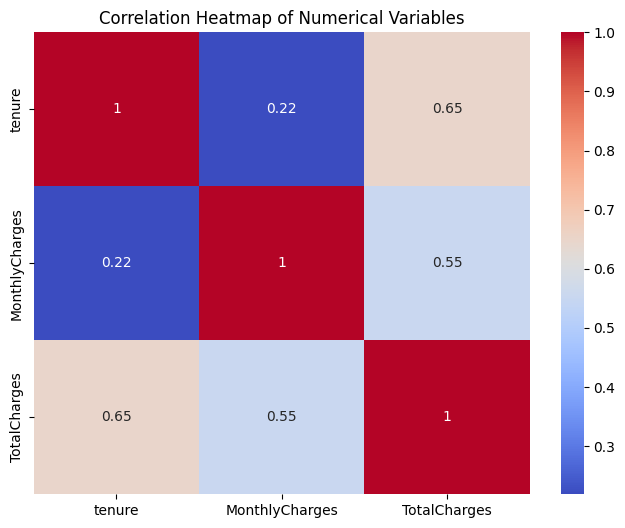

In [ ]:
plt.figure(figsize=(8,6))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

### Correlation Analysis Insights

Tenure and TotalCharges show a strong positive correlation, indicating potential multicollinearity. MonthlyCharges shows weaker correlation with tenure but contributes independently to churn behavior.

This insight is important for model building, as multicollinearity needs to be checked and handled during logistic regression using techniques such as Variance Inflation Factor (VIF).


## Key Insights from EDA

1. Customers on **month-to-month contracts** exhibit significantly higher churn compared to long-term contracts.
2. **Low-tenure customers** are at the highest risk of churn, especially within the first 12 months.
3. Customers using **electronic check** as a payment method show higher churn, indicating lower commitment.
4. **Fiber optic internet users** have higher churn, possibly due to pricing or service quality concerns.
5. Higher **monthly charges** increase churn risk, especially for new customers.

These insights indicate that churn is driven by a combination of pricing, contract flexibility, and customer tenure, making it essential to adopt targeted retention strategies.


## 4. Data Preprocessing


In [ ]:
df = df.drop(columns=['tenure_group'], errors='ignore')

In [ ]:
df['Churn_flag'] = df['Churn'].map({'No':0, 'Yes':1})
df[['Churn','Churn_flag']].head()

,Churn,Churn_flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [ ]:
X = df.drop(columns=['Churn','Churn_flag'])
y = df['Churn_flag']

X.shape, y.shape

((11199, 19), (11199,))

In [ ]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

cat_cols, num_cols

(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(X[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)
X_cat = pd.DataFrame(X_cat, columns=encoded_cols, index=X.index)

In [ ]:
X_num = X[num_cols]
X_final = pd.concat([X_num, X_cat], axis=1)
X_final.shape

(11199, 30)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((8399, 30), (2800, 30))

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train[num_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,8.399000e+03,8.399000e+03,8.399000e+03,8.399000e+03
mean,5.964194e-17,-2.548530e-17,-2.948257e-16,1.418082e-16
std,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00
min,-3.674235e-01,-1.283946e+00,-1.664325e+00,-1.030697e+00
25%,-3.674235e-01,-1.003064e+00,-9.791892e-01,-7.783024e-01
50%,-3.674235e-01,-1.202920e-01,2.233887e-01,-4.164141e-01
75%,-3.674235e-01,9.229841e-01,8.096455e-01,6.510374e-01
max,2.721655e+00,1.685378e+00,1.821815e+00,2.952981e+00


## 5. Baseline Model – Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8010714285714285
Precision: 0.6656441717791411
Recall: 0.5614489003880984
F1: 0.6091228070175438
ROC AUC: 0.8474000093179337

Confusion Matrix:
 [[1809  218]
 [ 339  434]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      2027
           1       0.67      0.56      0.61       773

    accuracy                           0.80      2800
   macro avg       0.75      0.73      0.74      2800
weighted avg       0.79      0.80      0.80      2800



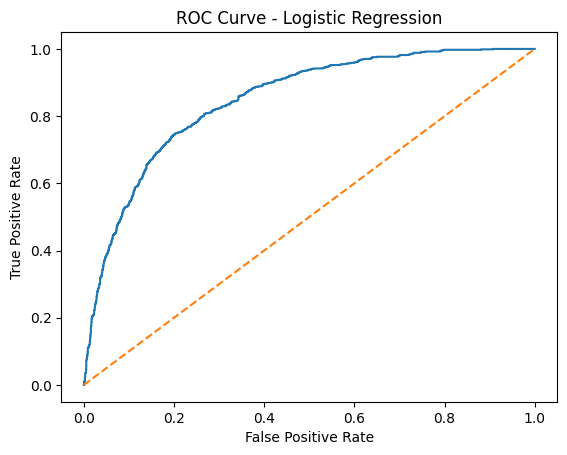

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

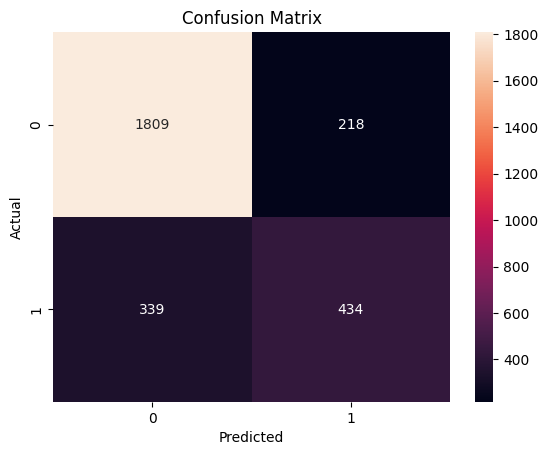

In [ ]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Baseline Model Building Approach – Logistic Regression

Logistic Regression is chosen as the baseline model because it is interpretable, suitable for binary classification, and allows statistical validation of feature significance.

Instead of using a solver-based approach alone, a statistical modeling approach is adopted to:
- Identify statistically significant predictors of churn
- Detect multicollinearity using Variance Inflation Factor (VIF)
- Iteratively refine the model by removing insignificant variables

This approach ensures both predictive performance and interpretability.


In [ ]:
df_sm = df.copy()

In [ ]:
# See EXACT raw values
df_sm['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
# Encode target variable
df_sm['Churn'] = df_sm['Churn'].replace({'Yes': 1, 'No': 0})

# Verify
df_sm['Churn'].value_counts()
df_sm['Churn'].dtype

/tmp/ipython-input-2648808162.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sm['Churn'] = df_sm['Churn'].replace({'Yes': 1, 'No': 0})


dtype('int64')

In [ ]:
df_sm.dtypes[df_sm.dtypes == 'object']

,0
gender,object
Partner,object
Dependents,object
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object
DeviceProtection,object
TechSupport,object


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

In [ ]:
# Logistic regression with feature importance (coefficients)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

feature_importance.head(10)

,Feature,Coefficient
25,Contract_Two year,-1.285827
22,StreamingMovies_No internet service,-0.965796
14,OnlineBackup_No internet service,-0.846384
24,Contract_One year,-0.758871
10,InternetService_Fiber optic,0.699788
1,tenure,-0.643537
18,TechSupport_No internet service,0.619566
28,PaymentMethod_electronic check,0.479170
19,TechSupport_Yes,-0.472234
9,MultipleLines_Yes,0.387797


### Multicollinearity Consideration

Correlation analysis showed a strong relationship between tenure and TotalCharges, which is expected since total charges accumulate over time. To avoid redundancy and instability in linear models, TotalCharges was excluded during model interpretation, while tenure was retained as a more fundamental behavioral indicator.

This approach reduces multicollinearity and improves interpretability of the baseline logistic regression model.

Advanced

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
def model_performance(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt_results = model_performance(dt, X_train, y_train, X_test, y_test)

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf_results = model_performance(rf, X_train, y_train, X_test, y_test)

In [ ]:
bag = BaggingClassifier(random_state=42)
bag_results = model_performance(bag, X_train, y_train, X_test, y_test)

In [ ]:
ada = AdaBoostClassifier(random_state=42)
ada_results = model_performance(ada, X_train, y_train, X_test, y_test)

In [ ]:
gb = GradientBoostingClassifier(random_state=42)
gb_results = model_performance(gb, X_train, y_train, X_test, y_test)

In [ ]:
advanced_results = pd.DataFrame([
    dt_results,
    rf_results,
    bag_results,
    ada_results,
    gb_results
], index=[
    "Decision Tree",
    "Random Forest",
    "Bagging",
    "AdaBoost",
    "Gradient Boosting"
])

advanced_results

,Accuracy,Precision,Recall,F1,ROC_AUC
Decision Tree,0.708214,0.472222,0.483829,0.477955,0.639320
Random Forest,0.796786,0.666124,0.529107,0.589762,0.826689
Bagging,0.771071,0.614187,0.459250,0.525537,0.775884
AdaBoost,0.801429,0.669797,0.553687,0.606232,0.841507
Gradient Boosting,0.816071,0.705414,0.573092,0.632405,0.850218


Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
dt_param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

dt_best = dt_grid.best_estimator_

In [ ]:
dt_tuned_results = model_performance(dt_best, X_train, y_train, X_test, y_test)
dt_tuned_results

{'Accuracy': 0.7942857142857143,
 'Precision': 0.6719022687609075,
 'Recall': 0.49805950840879687,
 'F1': 0.5720653789004457,
 'ROC_AUC': np.float64(0.8220973519836667)}

In [ ]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=1
)

rf_tuned_results = model_performance(rf_tuned, X_train, y_train, X_test, y_test)
rf_tuned_results

{'Accuracy': 0.8078571428571428,
 'Precision': 0.6923076923076923,
 'Recall': 0.5472186287192755,
 'F1': 0.611271676300578,
 'ROC_AUC': np.float64(0.8449996840837567)}

In [ ]:
ada_tuned = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_tuned_results = model_performance(ada_tuned, X_train, y_train, X_test, y_test)
ada_tuned_results

{'Accuracy': 0.7825,
 'Precision': 0.7009803921568627,
 'Recall': 0.36998706338939197,
 'F1': 0.48433530906011857,
 'ROC_AUC': np.float64(0.8348536669579052)}

In [ ]:
gb_tuned = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_tuned_results = model_performance(gb_tuned, X_train, y_train, X_test, y_test)
gb_tuned_results

{'Accuracy': 0.8142857142857143,
 'Precision': 0.6992125984251969,
 'Recall': 0.574385510996119,
 'F1': 0.6306818181818182,
 'ROC_AUC': np.float64(0.8505304520920994)}

In [ ]:
tuned_comparison = pd.DataFrame([
    dt_results,
    dt_tuned_results,
    rf_results,
    rf_tuned_results,
    ada_results,
    ada_tuned_results,
    gb_results,
    gb_tuned_results
], index=[
    "DT - Default", "DT - Tuned",
    "RF - Default", "RF - Tuned",
    "Ada - Default", "Ada - Tuned",
    "GB - Default", "GB - Tuned"
])

tuned_comparison

,Accuracy,Precision,Recall,F1,ROC_AUC
DT - Default,0.708214,0.472222,0.483829,0.477955,0.639320
DT - Tuned,0.794286,0.671902,0.498060,0.572065,0.822097
RF - Default,0.796786,0.666124,0.529107,0.589762,0.826689
RF - Tuned,0.807857,0.692308,0.547219,0.611272,0.845000
Ada - Default,0.801429,0.669797,0.553687,0.606232,0.841507
Ada - Tuned,0.782500,0.700980,0.369987,0.484335,0.834854
GB - Default,0.816071,0.705414,0.573092,0.632405,0.850218
GB - Tuned,0.814286,0.699213,0.574386,0.630682,0.850530
